<a href="https://colab.research.google.com/github/SulastriSyamsudin/PROJECT-UAS_SULASTRI/blob/main/Bow_StudiKasus2_Sulastri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import dan download Library dulu.

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

2. Masukkan Data Awal

In [1]:
Komentar_PunyaSulastri = [
    "Pelayanan akademik sangat baik",
    "Dosen ramah dan membantu",
    "WiFi kampus sering bermasalah",
    "Pelayanan administrasi lambat",
    "Fasilitas laboratorium sangat lengkap"
]

3. Biar lebih mudah, kita bikin function untuk

In [2]:
KomenButLower_PunyaSulastri = [teks.lower() for teks in Komentar_PunyaSulastri]
print("---- HASIL CASE FOLDING ----")
print(KomenButLower_PunyaSulastri, "\n")

---- HASIL CASE FOLDING ----
['pelayanan akademik sangat baik', 'dosen ramah dan membantu', 'wifi kampus sering bermasalah', 'pelayanan administrasi lambat', 'fasilitas laboratorium sangat lengkap'] 



4. Membuat Tokenization

In [3]:
# 2. Tokenization menggunakan split bawaan untuk melihat token awal.
token_PunyaSulastri = [teks.split() for teks in KomenButLower_PunyaSulastri]
print("---- HASIL TOKENIZATION ----")
for i, tok in enumerate(token_PunyaSulastri, 1):
    print(f"Dokumen {i}: {tok}")
print("\n")

---- HASIL TOKENIZATION ----
Dokumen 1: ['pelayanan', 'akademik', 'sangat', 'baik']
Dokumen 2: ['dosen', 'ramah', 'dan', 'membantu']
Dokumen 3: ['wifi', 'kampus', 'sering', 'bermasalah']
Dokumen 4: ['pelayanan', 'administrasi', 'lambat']
Dokumen 5: ['fasilitas', 'laboratorium', 'sangat', 'lengkap']




5. membuat Vocabulary dan Matriks BOW

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
# Buat Vocabulary & Matriks Bag of Words
# Kita pakai CountVectorizer agar otomatis membuat matriks BoW yang valid
Vectorizer_PunyaSulastri = CountVectorizer()
X = Vectorizer_PunyaSulastri.fit_transform(KomenButLower_PunyaSulastri)
vocabulary = Vectorizer_PunyaSulastri.get_feature_names_out()

print("=== VOCABULARY ===")
print(vocabulary, "\n")

print("=== MATRIKS BAG OF WORDS ===")
print(X.toarray(), "\n")

=== VOCABULARY ===
['administrasi' 'akademik' 'baik' 'bermasalah' 'dan' 'dosen' 'fasilitas'
 'kampus' 'laboratorium' 'lambat' 'lengkap' 'membantu' 'pelayanan' 'ramah'
 'sangat' 'sering' 'wifi'] 

=== MATRIKS BAG OF WORDS ===
[[0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1]
 [1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0]] 



6. Menentukan Kata yang sering munxul

In [ ]:
# Menghitung jumlah kemunculan tiap kata di seluruh dokumen
word_counts = np.asarray(X.sum(axis=0)).flatten()
counts_dict = dict(zip(vocabulary, word_counts))


7. Visualisasikan menggunakan Word Cloud

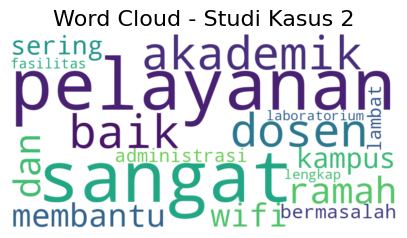

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
semua_teks = " ".join(KomenButLower_PunyaSulastri)

WordCloud_PunyaSulastri = WordCloud(width=800, height=400, background_color='white').generate(semua_teks)

plt.figure(figsize=(5, 5))
plt.imshow(WordCloud_PunyaSulastri, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Studi Kasus 2", fontsize=16)
plt.show()